# CNN 实战：CIFAR-10 彩色图片分类

MNIST 是灰度图（1通道），这次用 CIFAR-10 彩色图片（3通道）来训练 CNN。

### CIFAR-10 数据集

- 60000 张 32x32 彩色图片（50000 训练 + 10000 测试）
- 10 个类别：飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船、卡车
- 数据集大小：~170MB

### 和 MNIST 的区别

- MNIST：灰度图（1通道），28x28，数字识别，简单
- CIFAR-10：彩色图（3通道），32x32，自然物体识别，更难

自然图片的特征更复杂（纹理、颜色、形状），CNN 需要学习更多层才能提取有效特征。

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"设备: {device}")

设备: cuda


## 1. 加载 CIFAR-10 数据

CIFAR-10 的像素值也是 0-255，用 `ToTensor()` 归一化到 0-1。

额外加一步标准化（Normalize），让每个通道的均值为 0、标准差为 1，有助于训练稳定。

In [3]:
# CIFAR-10 的均值和标准差（官方统计值）
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"训练集: {len(train_dataset)} 张")
print(f"测试集: {len(test_dataset)} 张")
print(f"类别: {train_dataset.classes}")
print(f"图片形状: {train_dataset[0][0].shape}")  # (3, 32, 32)

100%|██████████| 170M/170M [00:10<00:00, 16.1MB/s] 


训练集: 50000 张
测试集: 10000 张
类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
图片形状: torch.Size([3, 32, 32])


## 2. 查看数据

CIFAR-10 是 RGB 彩色图，用 matplotlib 显示时需要把通道维放到最后：(C, H, W) → (H, W, C)。

/tmp/ipykernel_41175/2627989230.py:14: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/2627989230.py:14: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xstre/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


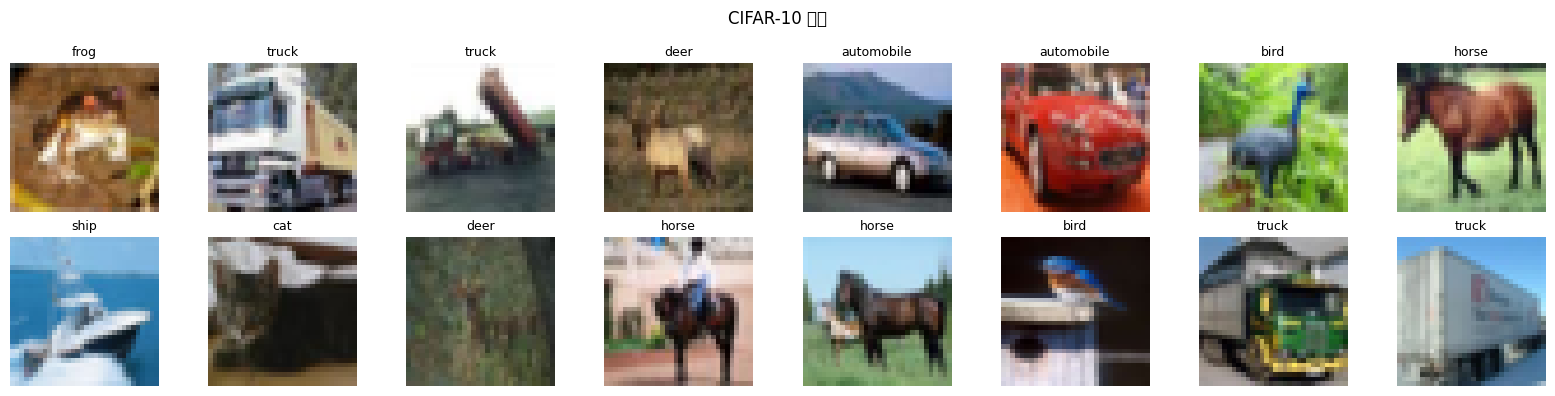

In [4]:
# 显示一些样本
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    img, label = train_dataset[i]
    # 反标准化，让图片恢复正常颜色
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    img = img.permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    img = np.clip(img, 0, 1)
    ax = axes[i // 8][i % 8]
    ax.imshow(img)
    ax.set_title(train_dataset.classes[label], fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 样本')
plt.tight_layout()
plt.show()

## 3. 定义 CNN 模型

和 MNIST 的 CNN 类似，但有几点不同：
- 输入通道从 1 改为 3（RGB 三通道）
- 多加一层卷积，因为彩色图片特征更复杂
- 加入 Dropout 防止过拟合（CIFAR-10 比 MNIST 更容易过拟合）

In [5]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # 第一组：3→32 通道
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # 32x32 → 16x16

            # 第二组：32→64 通道
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # 16x16 → 8x8

            # 第三组：64→128 通道
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),              # 8x8 → 4x4
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),              # 防止过拟合
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)     # 展平
        x = self.classifier(x)
        return x

model = CIFAR10CNN().to(device)
print(model)
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

CIFAR10CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

参数量: 620,362


## 4. 训练

CIFAR-10 比 MNIST 难很多，MNIST 能轻松到 99%，CIFAR-10 用简单 CNN 一般能达到 70-80%。

训练时间也更长，因为图片是彩色的（3通道），数据量更大。

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
train_losses = []
test_accs = []

for epoch in range(num_epochs):
    # === 训练 ===
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # === 验证 ===
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch).argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total * 100
    test_accs.append(acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] 损失: {avg_loss:.4f} 准确率: {acc:.2f}%")

Epoch [1/15] 损失: 1.4690 准确率: 59.73%
Epoch [2/15] 损失: 1.0944 准确率: 67.88%
Epoch [3/15] 损失: 0.9376 准确率: 70.81%
Epoch [4/15] 损失: 0.8460 准确率: 72.30%
Epoch [5/15] 损失: 0.7807 准确率: 74.66%
Epoch [6/15] 损失: 0.7319 准确率: 74.56%
Epoch [7/15] 损失: 0.6890 准确率: 76.90%
Epoch [8/15] 损失: 0.6565 准确率: 77.86%
Epoch [9/15] 损失: 0.6268 准确率: 77.17%
Epoch [10/15] 损失: 0.6091 准确率: 78.22%
Epoch [11/15] 损失: 0.5858 准确率: 77.56%
Epoch [12/15] 损失: 0.5583 准确率: 77.76%
Epoch [13/15] 损失: 0.5395 准确率: 78.61%
Epoch [14/15] 损失: 0.5250 准确率: 78.61%
Epoch [15/15] 损失: 0.5127 准确率: 78.83%


## 5. 可视化训练过程

/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/429470675.py:15: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}

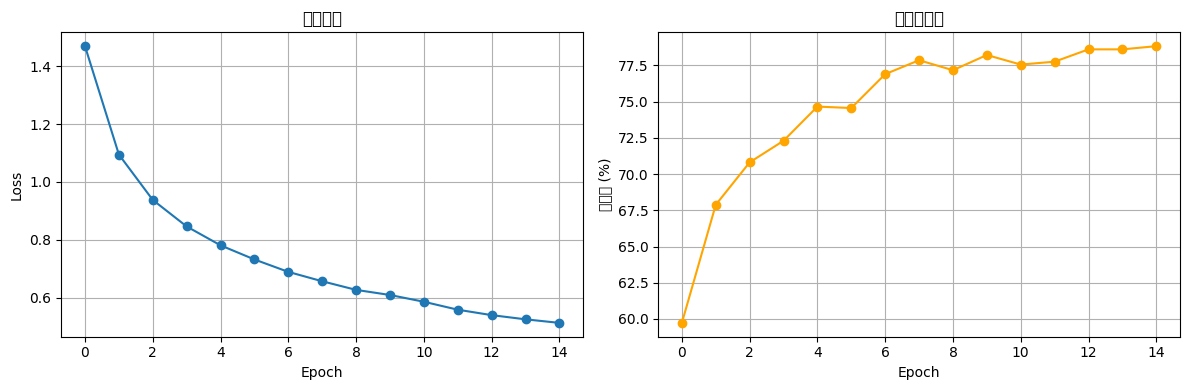

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o')
ax1.set_title('训练损失')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(test_accs, marker='o', color='orange')
ax2.set_title('测试准确率')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率 (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

## 6. 预测可视化

看看模型在彩色图片上的预测结果。

/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 32511 (\N{CJK UNIFIED IDEOGRAPH-7EFF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41175/1132216021.py:25: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAP

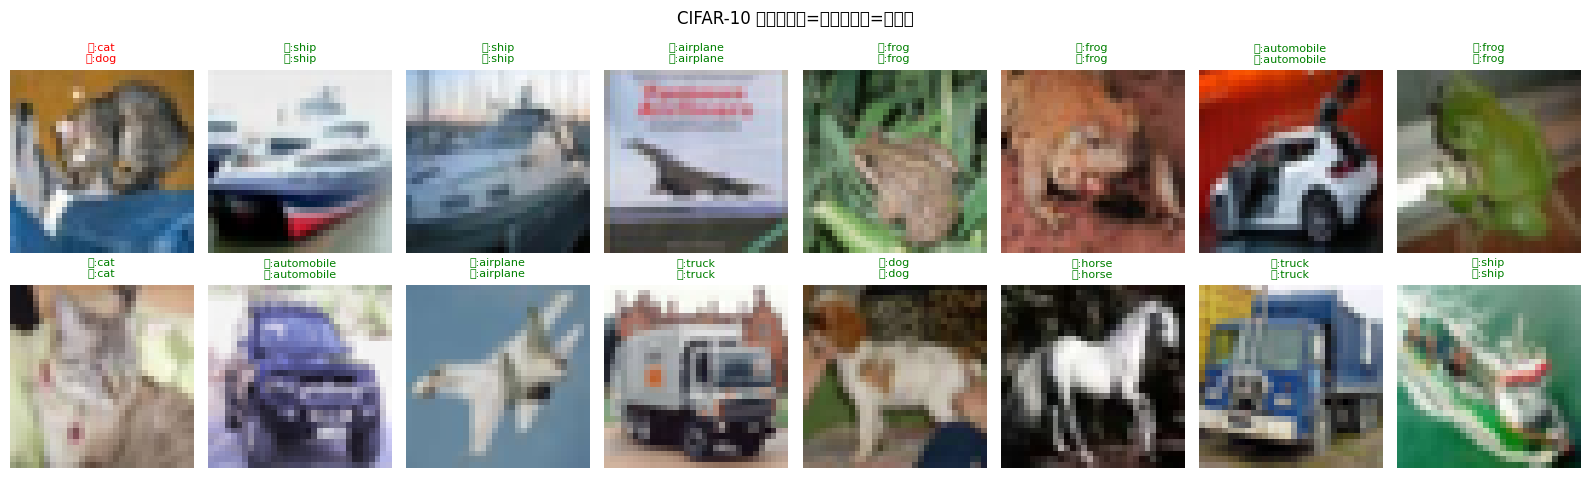

In [8]:
model.eval()
classes = train_dataset.classes

X_test, y_test = next(iter(test_loader))
X_test, y_test = X_test.to(device), y_test.to(device)

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(16):
    ax = axes[i // 8][i % 8]
    img = X_test[i].cpu()
    # 反标准化
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = classes[y_test[i].item()]
    pred_label = classes[preds[i].item()]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"真:{true_label}\n预:{pred_label}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('CIFAR-10 预测（绿色=正确，红色=错误）')
plt.tight_layout()
plt.show()

## 7. 每个类别的准确率

看看哪些类别容易识别，哪些容易混淆。

In [9]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch).argmax(dim=1)
        for i in range(len(y_batch)):
            label = y_batch[i].item()
            class_total[label] += 1
            if preds[i].item() == label:
                class_correct[label] += 1

print("各类别准确率:")
for i in range(10):
    acc = class_correct[i] / class_total[i] * 100
    print(f"  {classes[i]:>10s}: {acc:.1f}% ({class_correct[i]}/{class_total[i]})")

各类别准确率:
    airplane: 82.2% (822/1000)
  automobile: 87.6% (876/1000)
        bird: 70.1% (701/1000)
         cat: 60.3% (603/1000)
        deer: 76.4% (764/1000)
         dog: 76.8% (768/1000)
        frog: 81.6% (816/1000)
       horse: 81.4% (814/1000)
        ship: 81.4% (814/1000)
       truck: 90.5% (905/1000)


### 思考

简单 CNN 在 CIFAR-10 上一般能到 70-80%，远不如 MNIST 的 99%。原因：

1. 自然图片特征更复杂（纹理、颜色、形状、背景）
2. 类别间相似度高（猫 vs 鸟、汽车 vs 卡车）
3. 32x32 分辨率低，信息有限

要提升准确率，可以：
- 加数据增强（随机翻转、裁剪、颜色抖动）
- 用更深的网络（VGG、ResNet）
- 用学习率调度、权重衰减等训练技巧

这些内容在后续的 VGG/ResNet 笔记中会讲到。